In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score,confusion_matrix,accuracy_score, precision_score, recall_score, f1_score,fbeta_score, roc_curve, roc_auc_score, precision_recall_curve,auc, average_precision_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression, SGDRegressor, SGDClassifier, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, r2_score

In [2]:
df = pd.read_csv('C:\\Users\\User\\Documents\\ДЗ\\bmw.csv') 
df.head(10)

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,5 Series,2014,11200,Automatic,67068,Diesel,125,57.6,2.0
1,6 Series,2018,27000,Automatic,14827,Petrol,145,42.8,2.0
2,5 Series,2016,16000,Automatic,62794,Diesel,160,51.4,3.0
3,1 Series,2017,12750,Automatic,26676,Diesel,145,72.4,1.5
4,7 Series,2014,14500,Automatic,39554,Diesel,160,50.4,3.0
5,5 Series,2016,14900,Automatic,35309,Diesel,125,60.1,2.0
6,5 Series,2017,16000,Automatic,38538,Diesel,125,60.1,2.0
7,2 Series,2018,16250,Manual,10401,Petrol,145,52.3,1.5
8,4 Series,2017,14250,Manual,42668,Diesel,30,62.8,2.0
9,5 Series,2016,14250,Automatic,36099,Diesel,20,68.9,2.0


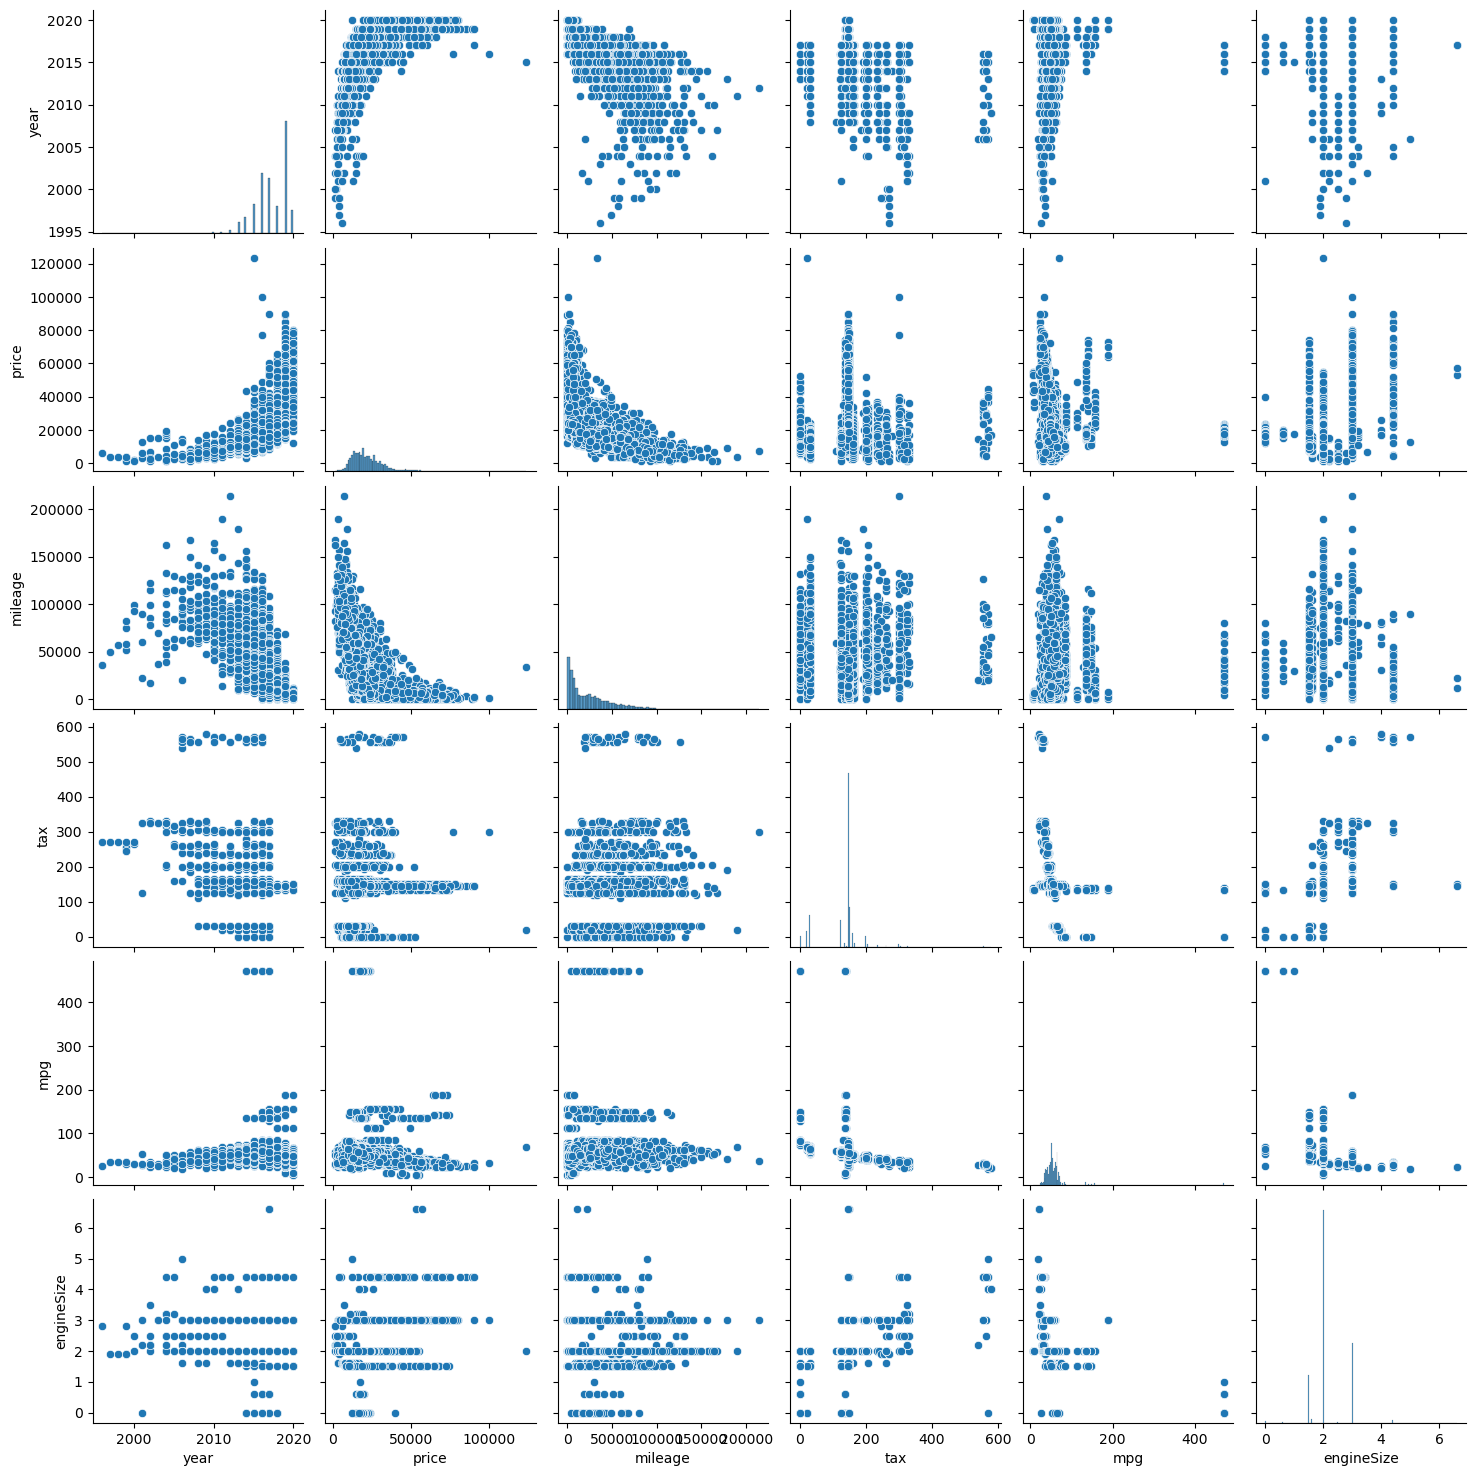

In [3]:
sns.pairplot(df)

In [7]:
##df["fuelType"] = df["fuelType"].apply(lambda x: 1 if x =='Diesel' else(2 if x =='Petrol' else(3 if x =='Hybrid' else 4)))

In [9]:
X = df.drop('price', axis=1)

In [10]:
y=df['price']

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,shuffle=True)

In [12]:
from sklearn.preprocessing import TargetEncoder

In [84]:
from sklearn.base import BaseEstimator, TransformerMixin


class MeanTargetEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, cols):
        self.cols = cols

    def fit(self, X, y):
        X = X.copy()
        df = X.copy()
        df[" target "] = y.values

        self.global_mean_ = y.mean()
        self.mapping_ = {}

        for col in self.cols:
            self.mapping_[col] = df.groupby(col)[" target "].mean().to_dict()

        return self

    def transform(self, X):
        X = X.copy()

        for col in self.cols:
            X[col] = X[col].map(self.mapping_[col])
            X[col] = X[col].fillna(self.global_mean_)

        return X

# Загружаем данные
df = pd.read_csv('C:\\Users\\User\\Documents\\ДЗ\\bmw.csv')

target = "price"

# Признаки и цель
X = df.drop(columns=[target])
y = df[target]

# Кодируем нужные столбцы
encoder = MeanTargetEncoder(cols=["model", "transmission", "fuelType"])

X_train_enc = encoder.fit_transform(X_train, y_train)
X_test_enc = encoder.transform(X_test)




In [85]:
X_train_enc

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize
3652,22649.220118,2019,27378.582860,9165,24287.777411,145,50.4,2.0
7007,39407.904509,2019,22351.619048,6650,21709.621290,145,37.7,3.0
9045,22649.220118,2016,22351.619048,64231,21709.621290,145,53.3,3.0
3910,57374.153846,2019,22351.619048,2799,27485.882845,135,141.2,1.5
3635,39407.904509,2013,22351.619048,63583,21709.621290,200,45.6,3.0
...,...,...,...,...,...,...,...,...
5734,19776.511236,2018,27378.582860,40456,21709.621290,145,64.2,2.0
5191,15757.759875,2016,27378.582860,23210,24287.777411,200,39.8,3.0
5390,28404.672489,2019,27378.582860,5652,21709.621290,145,47.9,2.0
860,19772.872240,2016,27378.582860,14542,21709.621290,125,60.1,2.0


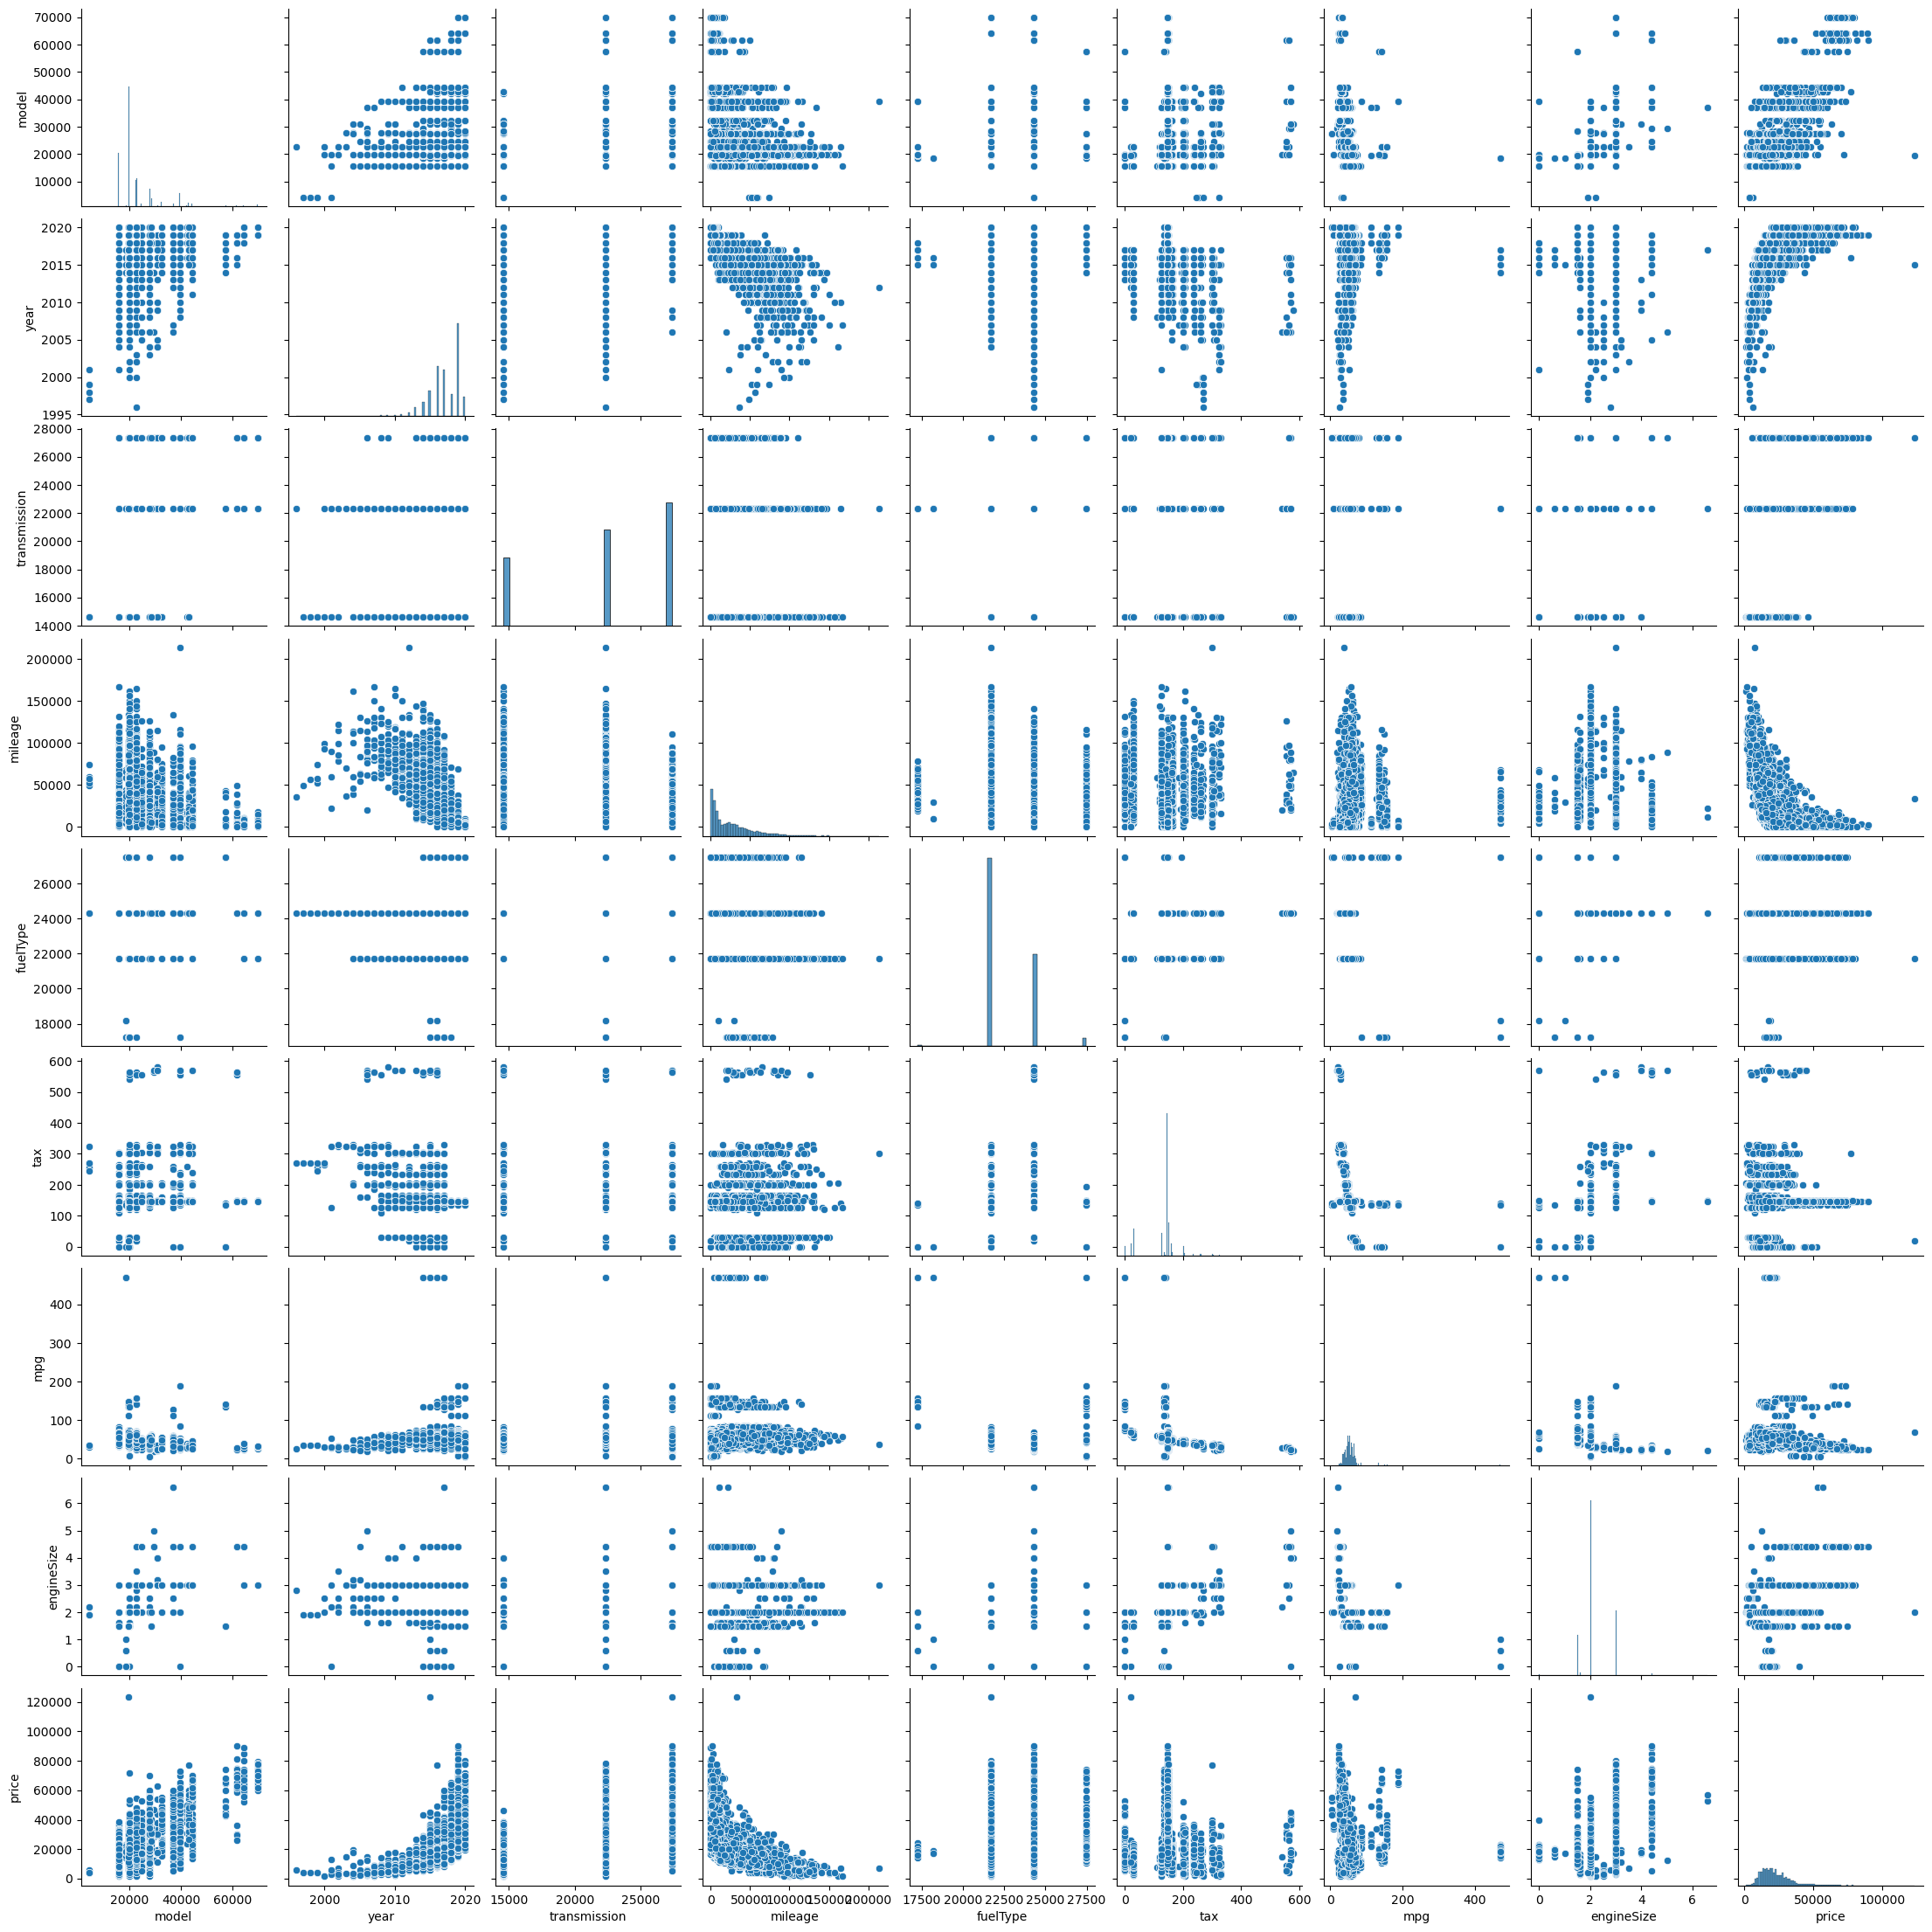

In [16]:
full_df = pd.concat([X_train_enc, y_train], axis=1)
sns.pairplot(full_df)

In [17]:
# Обучаем модель
model = LinearRegression()
model.fit(X_train_enc, y_train)

# Предсказание
y_pred = model.predict(X_test_enc)

# Метрики
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MAE: 3265.0536067728076
R2: 0.8270828546055077


In [18]:
model.coef_,model.intercept_ 

(array([ 7.23116811e-01,  1.52666790e+03,  1.32155493e-01, -1.24693876e-01,
         3.61946168e-01, -3.39795228e+00,  7.45903862e+00,  4.25318808e+03]),
 np.float64(-3090297.362407364))

In [19]:
from sklearn.model_selection import cross_val_score

In [20]:
cross_val_score(model,X_train_enc, y_train, cv=5).mean()

np.float64(0.8408606594897886)

In [ ]:
## Обучаем случайным лесом

In [21]:
from sklearn.ensemble import RandomForestRegressor

In [22]:
model1 = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model1.fit(X_train_enc, y_train)
y_pred1 = model1.predict(X_test_enc)

print("MAE:", mean_absolute_error(y_test, y_pred1))
print("R2:", r2_score(y_test, y_pred1))

MAE: 1599.1098899274618
R2: 0.9460799978323056


In [86]:
cross_val_score(model1,X_train_enc, y_train, cv=5).mean()

np.float64(0.9463185775989927)

In [87]:
## Оценка наиболее важных параметров для модели
importances = pd.Series(model1.feature_importances_, index=X_train_enc.columns)
print(importances.sort_values(ascending=False).head(10))

year            0.437975
model           0.371310
mileage         0.084210
mpg             0.041108
engineSize      0.026348
transmission    0.021821
tax             0.013445
fuelType        0.003783
dtype: float64


## Итого по результатам обуччения двух моделей лучше предсказывает модель случайного леса (это показывают метрики MAE, R2, а также результаты кроссвалидации)
## наиболее влияющую на таргет параметры оказались год , молеь и пробег машины

In [25]:
##Уровень 2

In [36]:
bmw = pd.read_csv('C:\\Users\\User\\Documents\\ДЗ\\bmw.csv') 
audi = pd.read_csv('C:\\Users\\User\\Documents\\ДЗ\\audi.csv')  
ford = pd.read_csv('C:\\Users\\User\\Documents\\ДЗ\\ford.csv')
hyundi = pd.read_csv('C:\\Users\\User\\Documents\\ДЗ\\hyundi.csv')
skoda = pd.read_csv('C:\\Users\\User\\Documents\\ДЗ\\skoda.csv')
toyota = pd.read_csv('C:\\Users\\User\\Documents\\ДЗ\\toyota.csv')
cclass = pd.read_csv('C:\\Users\\User\\Documents\\ДЗ\\cclass.csv')
focus = pd.read_csv('C:\\Users\\User\\Documents\\ДЗ\\focus.csv')
merc = pd.read_csv('C:\\Users\\User\\Documents\\ДЗ\\merc.csv')
vw = pd.read_csv('C:\\Users\\User\\Documents\\ДЗ\\vw.csv')

In [37]:
## объединяем все в один датафрейм
df = pd.concat([bmw,audi,ford,hyundi,skoda,toyota,cclass,focus,merc,vw],axis=0,ignore_index=True)
df

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,tax(£)
0,5 Series,2014,11200,Automatic,67068,Diesel,125.0,57.6,2.0,NaN
1,6 Series,2018,27000,Automatic,14827,Petrol,145.0,42.8,2.0,NaN
2,5 Series,2016,16000,Automatic,62794,Diesel,160.0,51.4,3.0,NaN
3,1 Series,2017,12750,Automatic,26676,Diesel,145.0,72.4,1.5,NaN
4,7 Series,2014,14500,Automatic,39554,Diesel,160.0,50.4,3.0,NaN
...,...,...,...,...,...,...,...,...,...,...
94903,Eos,2012,5990,Manual,74000,Diesel,125.0,58.9,2.0,NaN
94904,Fox,2008,1799,Manual,88102,Petrol,145.0,46.3,1.2,NaN
94905,Fox,2009,1590,Manual,70000,Petrol,200.0,42.0,1.4,NaN
94906,Fox,2006,1250,Manual,82704,Petrol,150.0,46.3,1.2,NaN


In [33]:
!pip install catboost

   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.5/100.2 MB 6.7 MB/s eta 0:00:15
    --------------------------------------- 2.4/100.2 MB 8.0 MB/s eta 0:00:13
   - -------------------------------------- 3.9/100.2 MB 7.8 MB/s eta 0:00:13
   -- ------------------------------------- 5.5/100.2 MB 7.6 MB/s eta 0:00:13
   -- ------------------------------------- 7.1/100.2 MB 7.8 MB/s eta 0:00:12
   --- ------------------------------------ 8.9/100.2 MB 8.0 MB/s eta 0:00:12
   ---- ----------------------------------- 10.7/100.2 MB 8.1 MB/s eta 0:00:12
   ---- ----------------------------------- 12.3/100.2 MB 8.1 MB/s eta 0:00:11
   ----- ---------------------------------- 14.2/100.2 MB 8.2 MB/s eta 0:00:11
   ------ --------------------------------- 16.0/100.2 MB 8.2 MB/s eta 0:00:11
   ------- -------------------------------- 17.8/100.2 MB 8.3 MB/s eta 0:00:10
   ------- -------------------------------- 19.4/100.2 MB 8.2 MB/s

In [34]:
from catboost import CatBoostRegressor

In [38]:
X = df.drop('price', axis=1)

In [39]:
y=df['price']

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,shuffle=True)

In [47]:
cat_features = X_train.select_dtypes(include=['object']).columns.tolist()

In [48]:
cat_features

['model', 'transmission', 'fuelType']

In [57]:
model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.5,
    depth=8,
    loss_function='MAE',
    random_seed=42,
    verbose=100
)

In [58]:
model.fit(
    X_train, y_train,
    cat_features=cat_features)

0:	learn: 4448.5840940	total: 32.3ms	remaining: 32.3s
100:	learn: 1349.8748678	total: 3.07s	remaining: 27.3s
200:	learn: 1226.0891677	total: 5.84s	remaining: 23.2s
300:	learn: 1171.2641376	total: 8.57s	remaining: 19.9s
400:	learn: 1140.8379406	total: 11.3s	remaining: 16.9s
500:	learn: 1121.7494422	total: 14s	remaining: 13.9s
600:	learn: 1106.6485113	total: 16.8s	remaining: 11.2s
700:	learn: 1093.2418075	total: 19.6s	remaining: 8.36s
800:	learn: 1084.8463081	total: 22.3s	remaining: 5.55s
900:	learn: 1075.5691436	total: 25s	remaining: 2.75s
999:	learn: 1069.0700959	total: 27.6s	remaining: 0us


CatBoostRegressor(depth=8, iterations=1000, learning_rate=0.5, loss_function='MAE', random_seed=42, verbose=100)

In [60]:
## Делаем прогноз
y_pred = model.predict(X_test)

## Считаем метрики
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae}")
print(f"R2: {r2}")

MAE: 1311.9890426010472
R2: 0.9422304976794972


In [ ]:
## теперь повторяем обучение линейной регрессии и случайнго леса для датафрейма с объединенными марками машин

In [61]:
class MeanTargetEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, cols):
        self.cols = cols

    def fit(self, X, y):
        X = X.copy()
        df = X.copy()
        df[" target "] = y.values

        self.global_mean_ = y.mean()
        self.mapping_ = {}

        for col in self.cols:
            self.mapping_[col] = df.groupby(col)[" target "].mean().to_dict()

        return self

    def transform(self, X):
        X = X.copy()

        for col in self.cols:
            X[col] = X[col].map(self.mapping_[col])
            X[col] = X[col].fillna(self.global_mean_)

        return X

# Загружаем данные
df = pd.read_csv('C:\\Users\\User\\Documents\\ДЗ\\bmw.csv')

target = "price"

# Признаки и цель
X = df.drop(columns=[target])
y = df[target]

# Делим train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Кодируем нужные столбцы
encoder = MeanTargetEncoder(cols=["model", "transmission", "fuelType"])

X_train_enc = encoder.fit_transform(X_train, y_train)
X_test_enc = encoder.transform(X_test)

# Если есть ещё текстовые столбцы — убираем их
X_train_enc = X_train_enc.select_dtypes(include="number")
X_test_enc = X_test_enc.select_dtypes(include="number")



In [62]:
X_train_enc

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize
3652,22649.220118,2019,27378.582860,9165,24287.777411,145,50.4,2.0
7007,39407.904509,2019,22351.619048,6650,21709.621290,145,37.7,3.0
9045,22649.220118,2016,22351.619048,64231,21709.621290,145,53.3,3.0
3910,57374.153846,2019,22351.619048,2799,27485.882845,135,141.2,1.5
3635,39407.904509,2013,22351.619048,63583,21709.621290,200,45.6,3.0
...,...,...,...,...,...,...,...,...
5734,19776.511236,2018,27378.582860,40456,21709.621290,145,64.2,2.0
5191,15757.759875,2016,27378.582860,23210,24287.777411,200,39.8,3.0
5390,28404.672489,2019,27378.582860,5652,21709.621290,145,47.9,2.0
860,19772.872240,2016,27378.582860,14542,21709.621290,125,60.1,2.0


In [63]:
# Обучаем модель
model_lin = LinearRegression()
model_lin.fit(X_train_enc, y_train)

# Предсказание
y_pred_lin = model_lin.predict(X_test_enc)

# Метрики
print("MAE:", mean_absolute_error(y_test, y_pred_lin))
print("R2:", r2_score(y_test, y_pred_lin))

MAE: 3265.0536067728076
R2: 0.8270828546055077


In [65]:
# Cлучвайный лес
model_forest = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model_forest.fit(X_train_enc, y_train)
y_pred_forest = model_forest.predict(X_test_enc)

print("MAE:", mean_absolute_error(y_test, y_pred_forest))
print("R2:", r2_score(y_test, y_pred_forest))

MAE: 1599.1098899274616
R2: 0.9460799978323056


In [ ]:
## Строим модель стекинга

In [66]:
from sklearn.ensemble import StackingRegressor

In [82]:
##Стекинг
stack_model = StackingRegressor(
    estimators=[
        ("cat", model),
        ("lin", model_lin),
        ("for", model_forest),
    ],
    final_estimator=LinearRegression(),
    passthrough=False,
    cv=5)

In [83]:
##Обучаем
stack_model.fit(X_train_enc, y_train)

##Предсказываем
y_pred = stack_model.predict(X_test_enc)

##Метрики
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae}")
print(f"R2: {r2}")

0:	learn: 5016.8326173	total: 2.76ms	remaining: 2.76s
100:	learn: 1132.1523113	total: 241ms	remaining: 2.15s
200:	learn: 1005.2858689	total: 480ms	remaining: 1.91s
300:	learn: 935.6669028	total: 719ms	remaining: 1.67s
400:	learn: 888.4612106	total: 949ms	remaining: 1.42s
500:	learn: 860.7143217	total: 1.18s	remaining: 1.17s
600:	learn: 836.9331478	total: 1.4s	remaining: 929ms
700:	learn: 817.7172420	total: 1.62s	remaining: 693ms
800:	learn: 804.2332676	total: 1.84s	remaining: 458ms
900:	learn: 790.3435315	total: 2.06s	remaining: 227ms
999:	learn: 780.5939580	total: 2.28s	remaining: 0us
0:	learn: 5005.7724298	total: 2.32ms	remaining: 2.32s
100:	learn: 1146.6877011	total: 222ms	remaining: 1.98s
200:	learn: 999.7192206	total: 437ms	remaining: 1.74s
300:	learn: 927.0887774	total: 646ms	remaining: 1.5s
400:	learn: 884.7317064	total: 854ms	remaining: 1.28s
500:	learn: 850.8781534	total: 1.06s	remaining: 1.06s
600:	learn: 819.0122033	total: 1.29s	remaining: 855ms
700:	learn: 799.1755256	total